In [1]:
from parts import *

In [2]:
%%capture
FIG_14_6.plot(True)
A_15_8.plot()
A_15_9.plot()

In [3]:
%%capture
RetainingRing.ensure_loaded()

fig, ax = A_15_16.plot(True)
sc1 = ax.scatter(RetainingRing.df["a_t_book"], RetainingRing.df["K_t"], c=RetainingRing.df["D_book"], s=12, zorder=10)
fig.colorbar(sc1, ax=ax, label="D_book")

fig, ax = A_15_17.plot(True)
sc2 = ax.scatter(RetainingRing.df["a_t_book"], RetainingRing.df["K_ts"], c=RetainingRing.df["D_book"], s=12, zorder=10)
fig.colorbar(sc2, ax=ax, label="D_book")

{'gear_ratio_1': 5.0, 'module_1': 2.0, 'module_2': 3.0, 'phi_1': 20.0, 'phi_2': 20.0, 'N_2': 17.0, 'N_4': 19.0, 'F_1': 30.322061420206538, 'F_2': 46.00514662313241, 'L_1': 0.10982173999136553, 'L_2': 0.21986986029728464, 'd_shaft_gear_1': 35.54840130400399, 'd_shaft_gear_2': 27.50021175680342, 'd_shaft_shoulder': 43.30229411123095}
gearbox.min_fos = np.float64(0.806668601825903)
gearbox.depth = np.float64(390.5)
gearbox.min_fos_key = 'n_fatigue_ring_2'
gearbox.fos_dict = {'stage_1.pinion.n_b': np.float64(1.3780205724669439), 'stage_1.pinion.n_c': np.float64(1.097327276861069), 'stage_1.gear.n_b': np.float64(1.9788188171152552), 'stage_1.gear.n_c': np.float64(1.2226308048528711), 'stage_2.pinion.n_b': np.float64(1.3796489837932513), 'stage_2.pinion.n_c': np.float64(1.1754088539001573), 'stage_2.gear.n_b': np.float64(1.8277937642911093), 'stage_2.gear.n_c': np.float64(1.288139587797694), 'n_fatigue_ring_1': np.float64(13.235170281816494), 'n_fatigue_ring_2': np.float64(0.806668601825903)

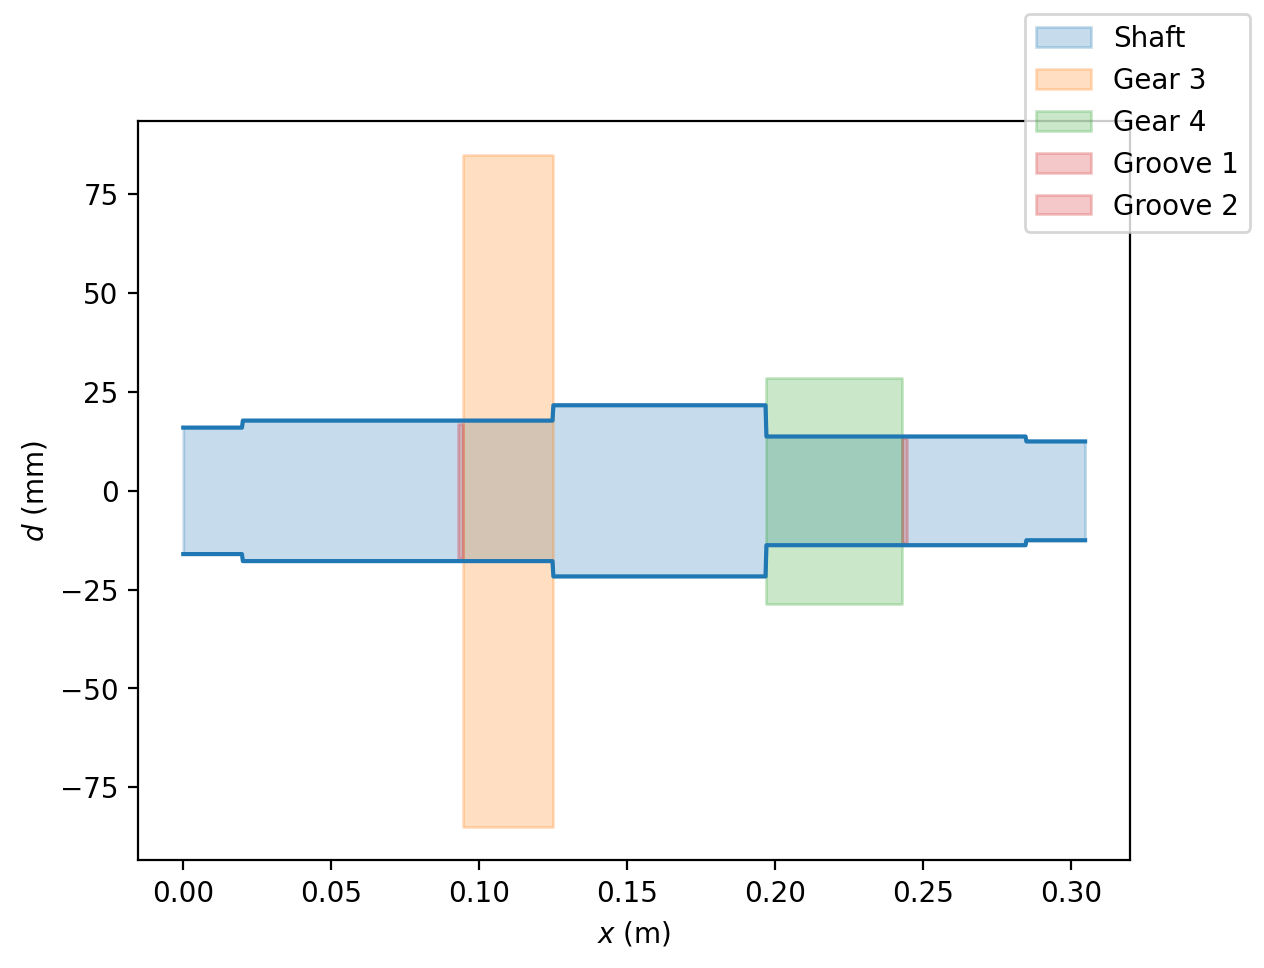

In [4]:
# x = [2, 4, 6, 1, 1, 1,  3, 0.9036235826506305, 1.0, 0.8124274696359233, 0.7134705498169797, 0.7269735241599499, 0.755249887362642, 0.9518742128933368]
# x = [1.0, 4.0, 6.0, 1.0, 1.0, 3.0, 3.0, 0.8142093341215075, 0.35369519529842414, 0.12404077751492298, 0.4625935879856248, 0.8152245755646447, 0.9675631480470787, 0.5202012251107094]
x = [2, 4, 6, 1, 1, 1,  3, 0.9129529798809635, 0.9406488309129802, 0.6507688647585756, 0.5533945234357338, 0.6788533623111997, 0.750007058560114, 0.2102243679607237]

gearbox = Gearbox.from_scaled(x)
print(gearbox.kwargs)
print(f"{gearbox.min_fos = }")
print(f"{gearbox.depth = }")
print(f"{gearbox.min_fos_key = }")
print(f"{gearbox.fos_dict = }")
print(f"{gearbox.shaft.bearing_A.F_R = }")
print(f"{gearbox.shaft.bearing_B.F_R = }")
gearbox.shaft.key_1.print()
gearbox.shaft.key_2.print()
# print(gearbox.shaft.stage_1.gear.N)
# print(gearbox.shaft.stage_2.pinion.N)
print(gearbox.shaft.R_A)
print(gearbox.shaft.R_B)
print(gearbox.shaft.stage_1.pinion.N, gearbox.shaft.stage_1.gear.N)
print(gearbox.shaft.stage_2.pinion.N, gearbox.shaft.stage_2.gear.N)
gearbox.shaft.plot_diagrams()
print(gearbox.shaft.reactions)
print(gearbox.shaft.R_A_y)
gearbox.export_input_parameters("iter_2")

In [5]:
# final gearbox

manual_kwargs = dict(
    gear_ratio_1 = 5,
    module_1 = 2.0, # mm/teeth
    module_2 = 3.0, # mm/teeth
    phi_1 = 20.0, # deg
    phi_2 = 20.0, # deg
    N_2 = 20,
    N_4 = 20,
    F_1 = 20, # mm
    F_2 = 30, # mm
    L_1 = 0.1, # m
    L_2 = 0.22, # m
    d_shaft_gear_1 = 35, # mm
    d_shaft_gear_2 = 30, # mm
    d_shaft_shoulder = 50, # mm
    bearing_A_width = 17.0,
    bearing_B_width = 19.0,
    extra_bearing_A_kwargs = dict(ID = 25.0, r = 1.0, C_10 = 22.9e3, part_number = "SKF 305"),
    extra_bearing_B_kwargs = dict(ID = 20.0, r = 1.0, C_10 = 30.7e3, part_number = "SKF 6404"),
    extra_key_1_kwargs = dict(gear_hub_width=36.0, w=10.0, h=np.ceil(3.3*2)),
    extra_key_2_kwargs = dict(gear_hub_width=50.0, w=8.0, h=np.ceil(3.3*2)),
)

manual_gearbox = Gearbox(**manual_kwargs)

print(f"desired {gearbox.min_fos = }")
print(f"desired {gearbox.depth = }")
print()
print(f"{manual_gearbox.min_fos = }")
print(f"{manual_gearbox.depth = }")
print()

print(f"{manual_gearbox.min_fos_key = }")
print(f"{manual_gearbox.fos_dict = }")

pprint.pprint(sorted( ((v,k) for k,v in manual_gearbox.fos_dict.items())))

print(f"{manual_gearbox.shaft.bearing_A.F_R = }")
print(f"{manual_gearbox.shaft.bearing_B.F_R = }")

print(manual_gearbox.shaft.key_1.L)
print(manual_gearbox.shaft.key_2.L)

print(vars(manual_gearbox.shaft.ring_1))
print(vars(manual_gearbox.shaft.ring_2))

print(manual_gearbox.shaft.bearing_A.r)
print(manual_gearbox.shaft.bearing_B.r)
print(manual_gearbox.shaft.stage_1.pinion.N, manual_gearbox.shaft.stage_1.gear.N)
print(manual_gearbox.shaft.stage_2.pinion.N, manual_gearbox.shaft.stage_2.gear.N)

manual_gearbox.export_CAD_parameters()
manual_gearbox.export_tables()

desired gearbox.min_fos = np.float64(0.806668601825903)
desired gearbox.depth = np.float64(390.5)

manual_gearbox.min_fos = np.float64(1.001601404738279)
manual_gearbox.depth = np.float64(425.0)

manual_gearbox.min_fos_key = 'stage_2.pinion.n_b'
manual_gearbox.fos_dict = {'stage_1.pinion.n_b': np.float64(1.1820843652106088), 'stage_1.pinion.n_c': np.float64(1.0561817935600752), 'stage_1.gear.n_b': np.float64(1.5618276610930104), 'stage_1.gear.n_c': np.float64(1.1557954943012945), 'stage_2.pinion.n_b': np.float64(1.001601404738279), 'stage_2.pinion.n_c': np.float64(1.0177432551020258), 'stage_2.gear.n_b': np.float64(1.281459535015157), 'stage_2.gear.n_c': np.float64(1.0999009885429751), 'n_fatigue_ring_1': np.float64(12.639921045808519), 'n_fatigue_ring_2': np.float64(1.3024206948488504), 'n_fatigue_shoulder_1': np.float64(9.426497256383898), 'n_fatigue_shoulder_2': np.float64(1.7536090376338669), 'n_fatigue_shoulder_A': np.float64(79.3761864574478), 'n_fatigue_shoulder_B': np.float64(3

In [6]:
vars(manual_gearbox.shaft.stage_1)

{'pinion': <parts.Gear at 0x1dbf14e2b10>,
 'gear': <parts.Gear at 0x1dbf1cecc90>,
 'gear_ratio_m': np.int64(5),
 'center_d': np.float64(120.0),
 'W_t': 1780.2273103769046,
 'W_r': np.float64(647.9497512049733),
 'W': np.float64(1894.4783336576786),
 'V': 20.943951023931955,
 'L': 0.1}

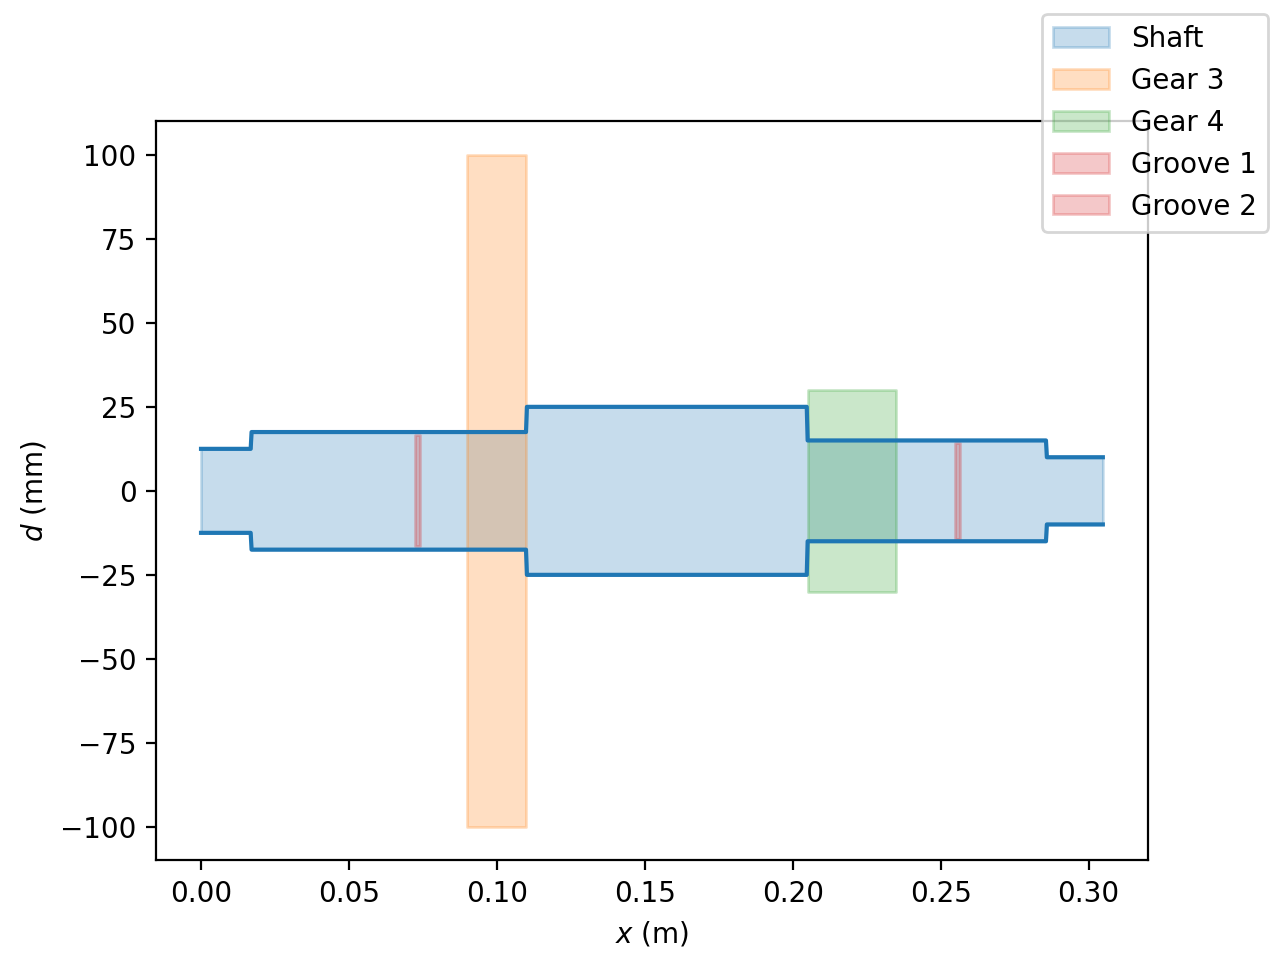

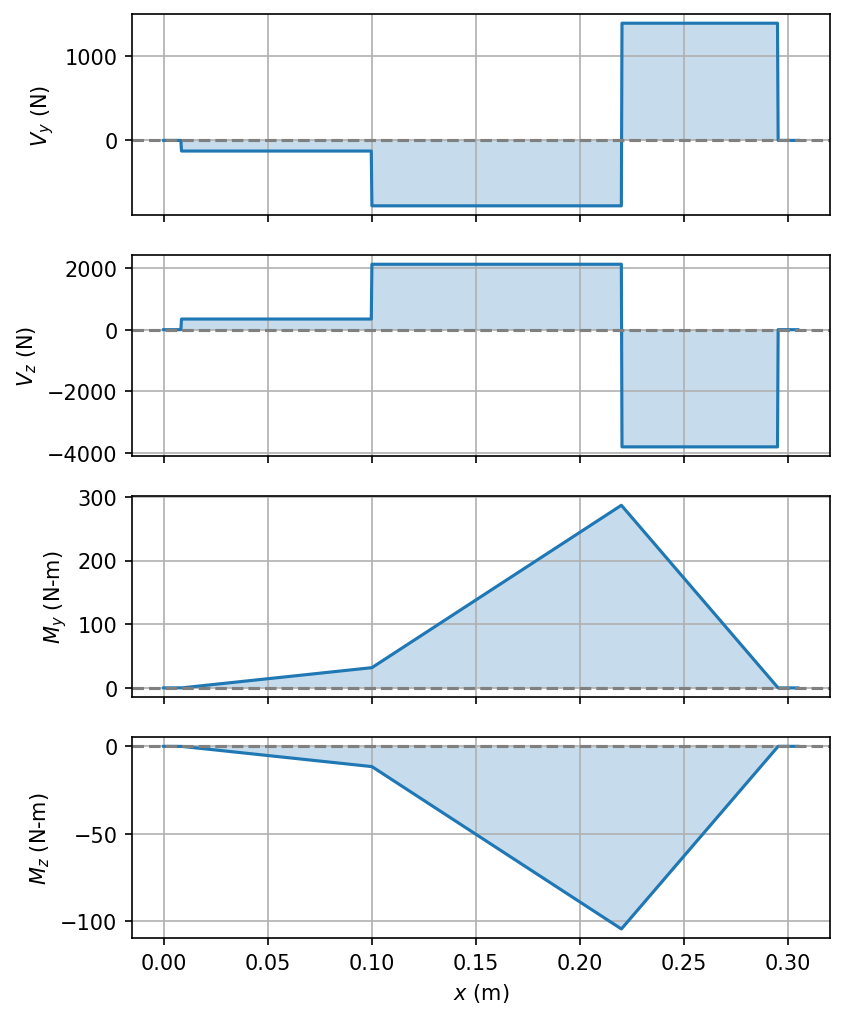

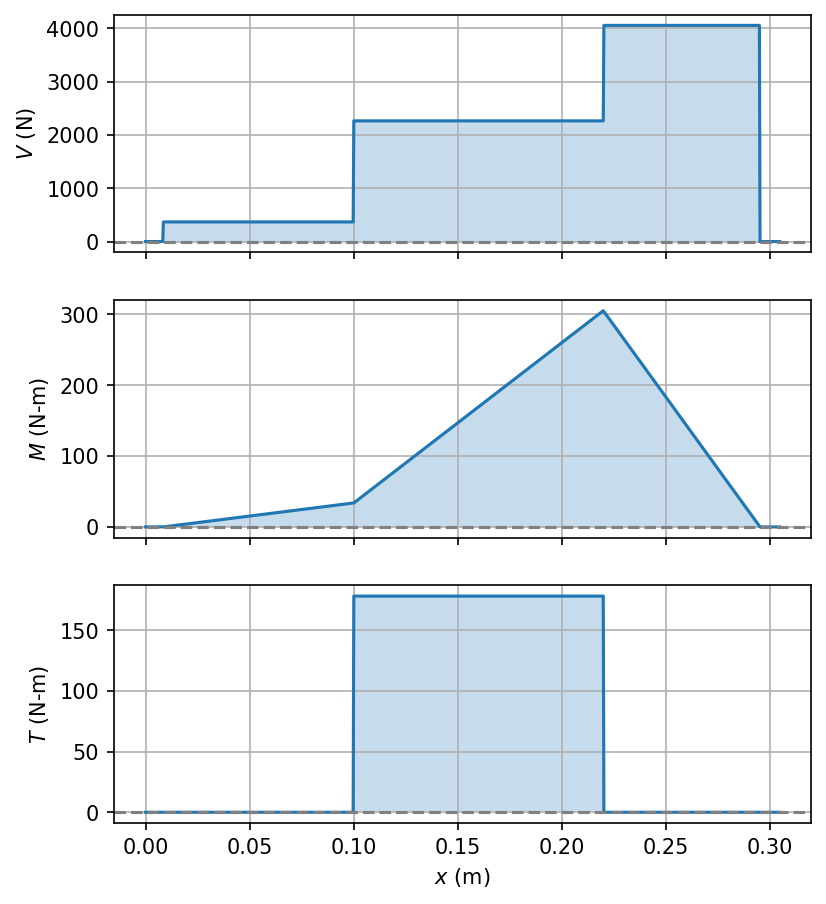

In [7]:
# %%capture
manual_gearbox.shaft.plot_diagrams(show_VMT=True, is_saving=True)